In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

In [7]:
excel_file = 'Cleaned_Customers_Dataset.xlsx'
df = pd.read_excel(excel_file)

city_stats = df.groupby('city').agg(
    customer_count=('customer_id', 'nunique'),
    total_revenue=('total_spending', 'sum'),
    avg_spending_per_customer=('total_spending', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    total_purchases=('purchase_count', 'sum'),
    total_returned=('returned_items', 'sum')
).reset_index()

city_stats['return_rate_pct'] = (city_stats['total_returned'] / city_stats['total_purchases']) * 100

print(city_stats.to_string())

      city  customer_count  total_revenue  avg_spending_per_customer  avg_satisfaction  total_purchases  total_returned  return_rate_pct
0    Ahvaz               8       23384.78                2923.097500          3.500000              111              26        23.423423
1  Isfahan               5       21975.32                4395.064000          4.400000               99              22        22.222222
2    Karaj               7       26189.81                3741.401429          2.857143              112              34        30.357143
3  Mashhad              11       43197.58                3927.052727          2.909091              249              29        11.646586
4    Rasht               5       15168.54                3033.708000          2.600000               82              17        20.731707
5   Shiraz               6       20715.92                3452.653333          2.000000               98              29        29.591837
6   Tabriz              12       36192.49

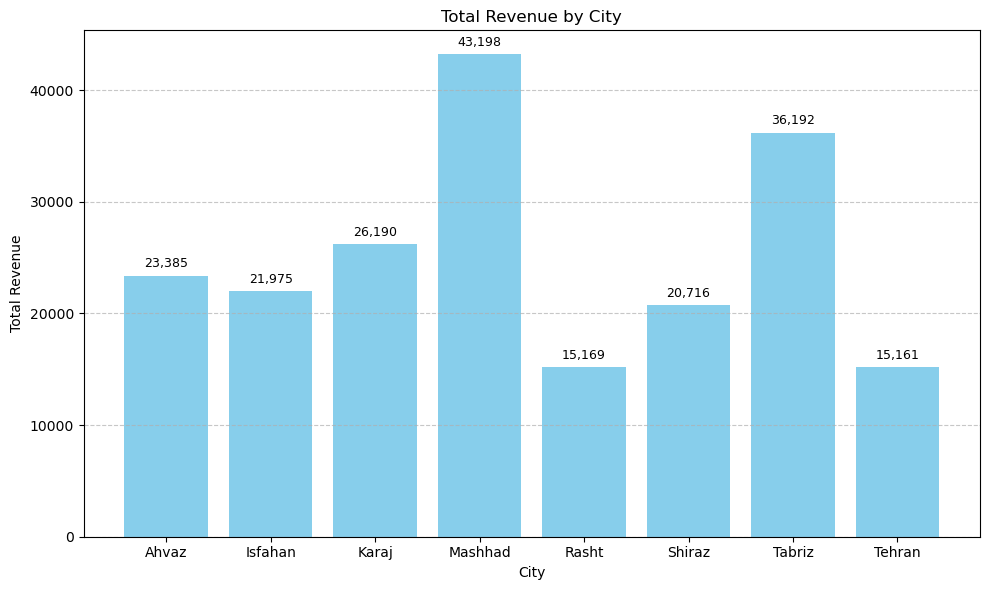

In [16]:
plt.figure(figsize=(10, 6))
bars = plt.bar(city_stats['city'], city_stats['total_revenue'], color='skyblue')
plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, f'{yval:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
plt.close()